xtrack version 0.82.4


/Users/santiagomartinez/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


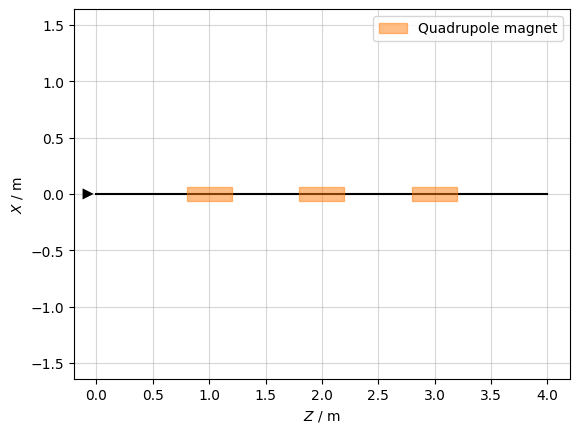

In [1]:
#import useful libraries
import numpy as np  # arrays and math
import matplotlib.pyplot as plt  # plots
import xtrack as xt  # tracking module of Xsuite
#%matplotlib widget
print('xtrack version', xt.__version__)

# Reference energy
part = xt.Particles(mass0=xt.PROTON_MASS_EV, p0c=1e9)  # Mass eV/c^2 Momentum in eV/c

# Element geometry
env=xt.Environment()
env.vars.default_to_zero = True
env['l_mq'] = 0.4


env.new('mq', xt.Quadrupole, length='l_mq')
env.new('qf', 'mq', k1='kqf') # Focusing quadrupole  k1>0
env.new('qd', 'mq', k1='kqd') # De-focusing quadrupole k1<0
#Markers
env.new("start_cell",xt.Marker)
env.new("end_cell",xt.Marker)


line = env.new_line(
    length=4, # 6 m length
    components=[
    env.place('start_cell', at=0),
    env.place('qf', at=1),
    env.place('qd', at=2),   # refer to the center by default
    env.place('qf', at=3),
    env.place('end_cell',at=4),
    ]
)
line.survey().plot()
line.particle_ref=part


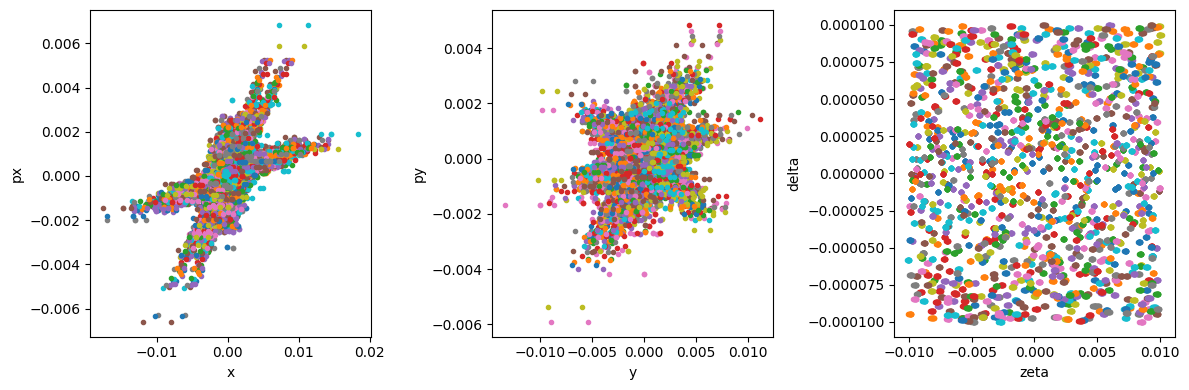

In [44]:
#Particles distribution



total_particles = 50000
training_batch_size = 1250
n_training_batches = total_particles // training_batch_size

# Define the initial distribution of particles in phase space
# Here we use a Gaussian distribution for the initial conditions
# You can adjust the mean and standard deviation as needed
mean = [0, 0, 0, 0]  # mean for x, px, y, py
std_dev = [1e-3, 1e-3, 1e-3, 1e-3]  # standard deviation for x, px, y, py
initial_conditions = np.random.normal(loc=mean, scale=std_dev, size=(training_batch_size, 4))   


p0=line.build_particles(
    x =initial_conditions[:, 0], px= initial_conditions[:, 1],
    y =initial_conditions[:, 2], py= initial_conditions[:, 3],
    zeta=np.random.uniform(-1e-2, 1e-2, training_batch_size), delta=np.random.uniform(-1e-4, 1e-4, training_batch_size))
env['kqf']=1; env['kqd']=-2
line.track(p0,turn_by_turn_monitor="ONE_TURN_EBE")
data=line.record_last_track
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,4))
ax1.plot(data.x.T,data.px.T,'.')
ax2.plot(data.y.T,data.py.T,'.')
ax3.plot(data.zeta.T,data.delta.T,'.')
ax1.set_xlabel("x"); ax1.set_ylabel("px")
ax2.set_xlabel("y"); ax2.set_ylabel("py")
ax3.set_xlabel("zeta"); ax3.set_ylabel("delta")
fig.tight_layout()